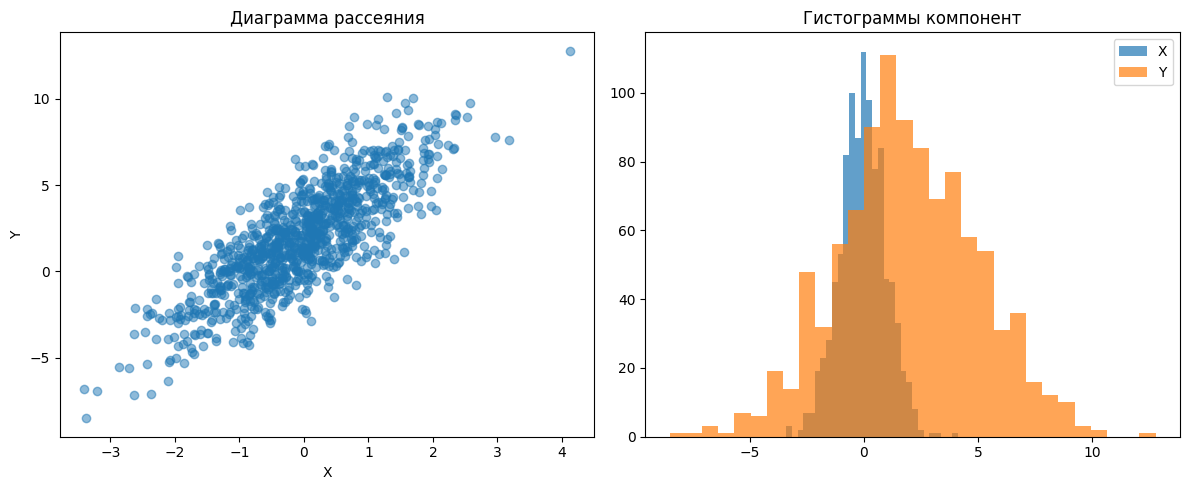

Характеристики X:
Среднее: -0.05
Ст. отклонение: 1.01

Характеристики Y:
Среднее: 1.92
Ст. отклонение: 3.05

Выборочный коэффициент корреляции: 0.814
95% ДИ: (0.792, 0.834)

p-value: 0.0000
Отвергаем H0: корреляция значима


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Параметры распределения
n = 1000
mX, mY = 0, 2
sigmaX, sigmaY = 1, 3
rho = 0.8
# 1. Генерация выборки
cov = rho * sigmaX * sigmaY
cov_matrix = [[sigmaX**2, cov], [cov, sigmaY**2]]
data = np.random.multivariate_normal(mean=[mX, mY], cov=cov_matrix, size=n)

# 2. Диаграмма рассеяния
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(data[:,0], data[:,1], alpha=0.5)
plt.title('Диаграмма рассеяния')
plt.xlabel('X')
plt.ylabel('Y')

# 3. Гистограммы компонент
plt.subplot(1, 2, 2)
plt.hist(data[:,0], bins=30, alpha=0.7, label='X')
plt.hist(data[:,1], bins=30, alpha=0.7, label='Y')
plt.title('Гистограммы компонент')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Выборочные характеристики
print("Характеристики X:")
print(f"Среднее: {np.mean(data[:,0]):.2f}")
print(f"Ст. отклонение: {np.std(data[:,0]):.2f}")

print("\nХарактеристики Y:")
print(f"Среднее: {np.mean(data[:,1]):.2f}")
print(f"Ст. отклонение: {np.std(data[:,1]):.2f}")

# 5. Коэффициент корреляции Пирсона
r, p_value = stats.pearsonr(data[:,0], data[:,1])
print(f"\nВыборочный коэффициент корреляции: {r:.3f}")

# 6. Доверительный интервал для r (alpha=0.95)
z = np.arctanh(r)
se = 1 / np.sqrt(n - 3)
z_low = z - 1.96 * se
z_high = z + 1.96 * se
r_low = np.tanh(z_low)
r_high = np.tanh(z_high)
print(f"95% ДИ: ({r_low:.3f}, {r_high:.3f})")

# 7. Проверка гипотезы H0: rho = 0
alpha = 0.05
print(f"\np-value: {p_value:.4f}")
if p_value < alpha:
    print("Отвергаем H0: корреляция значима")
else:
    print("Не отвергаем H0: корреляция незначима")